# Exploratory Data Analysis – Quantitative Impact of Global and Domestic Events on the BIST
This notebook presents the main exploratory data analysis (EDA) for the project:
**Quantitative Impact of Global and Domestic Events on the BIST (Turkish Stock Exchange)**

The goal is to visually and statistically inspect how macro-shocks (geopolitical events, economic announcements, etc.) relate to the BIST 100 performance, specifically in USD-adjusted terms to account for currency volatility.

The notebook is organised as follows:
1. **Setup and Data Loading:** Initializing paths and libraries.
2. **Data Alignment (Trading Day Logic):** Mapping weekend/holiday events to market sessions.
3. **Market Performance vs. Shocks (H1):** Visualizing the price action and shock severity.
4. **Volatility Analysis:** Inspecting the frequency and magnitude of market reactions.

## [1] Data Loading and Temporal Alignment
Loads the unified BIST dataset and aligns non-trading day shock events to the next available market session for accurate visualization.

In [1]:
import pandas as pd            # For data manipulation, handling DataFrames, and time-series alignment (e.g., merging daily and shock data)
import numpy as np             # For numerical operations, handling arrays, and math (used for calculating standard errors and trendlines)
from pathlib import Path       # For modern, object-oriented file path handling 
import os                      # For interacting with the operating system (checking if files/directories exist before trying to load them)
import matplotlib.pyplot as plt # The core plotting engine used to build the foundations of our line charts, scatter plots, and event overlays
import seaborn as sns          # For high-level, professional statistical visualizations and styling (like the "whitegrid" theme and boxplots)
import scipy.stats as stats    # For advanced statistical testing (specifically used for the Mann-Whitney U test to prove volatility shifts)

# Path Configuration: Notebook is in 'eda/', data is in 'data_collection/processed/'
DATA_PROCESSED = Path("..") / "data_collection" / "processed"

output_dir = Path("Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

try:
    # 1. Data Loading
    # Load primary BIST dataset with technical indicators (Enriched)
    df_daily = pd.read_csv(DATA_PROCESSED / "unified_bist_enriched.csv", parse_dates=['date']).sort_values('date')
    
    # Load the catalog of external shock events
    df_shocks = pd.read_csv(DATA_PROCESSED / "shock_analysis_summary.csv", parse_dates=['date']).sort_values('date')

    # 2. TEMPORAL ALIGNMENT
    # Maps shocks occurring on weekends or holidays to the next available trading day.
    # The 'forward' direction ensures a Saturday/Sunday event is mapped to Monday's market data.
    df_aligned_shocks = pd.merge_asof(
        df_shocks, 
        df_daily[['date', 'close', 'daily_return_pct', 'volatility_7d']], 
        on='date', 
        direction='forward'
    )

    print("✅ LIBRARIES AND DATASETS LOADED SUCCESSFULLY")
    print(f"Aligned Shocks: {len(df_aligned_shocks)} / {len(df_shocks)}")
    print(f"BIST Date Range: {df_daily['date'].min().date()} to {df_daily['date'].max().date()}")

except FileNotFoundError as e:
    print(f"❌ ERROR: File path not found! Python looked at: {DATA_PROCESSED.resolve()}")
    print(f"Error Details: {e}")

# Proceed with analysis using 'df_daily' and 'df_aligned_shocks'

✅ LIBRARIES AND DATASETS LOADED SUCCESSFULLY
Aligned Shocks: 24 / 24
BIST Date Range: 2015-01-02 to 2026-04-03


## [2] Visualization: BIST 100 Performance & External Shock Overlay
This chart visualizes the BIST 100 index from 2015 to the present, highlighting the precise moments when major external shocks occurred. 
* **Red Markers**: Represent the 24 identified shocks, correctly aligned to the nearest trading day.
* **Text Annotations**: Specifically highlight events categorized as **'Extreme'** severity (e.g., Coup Attempt, COVID-19 Pandemic, Currency Crisis) to observe their immediate impact on price action.

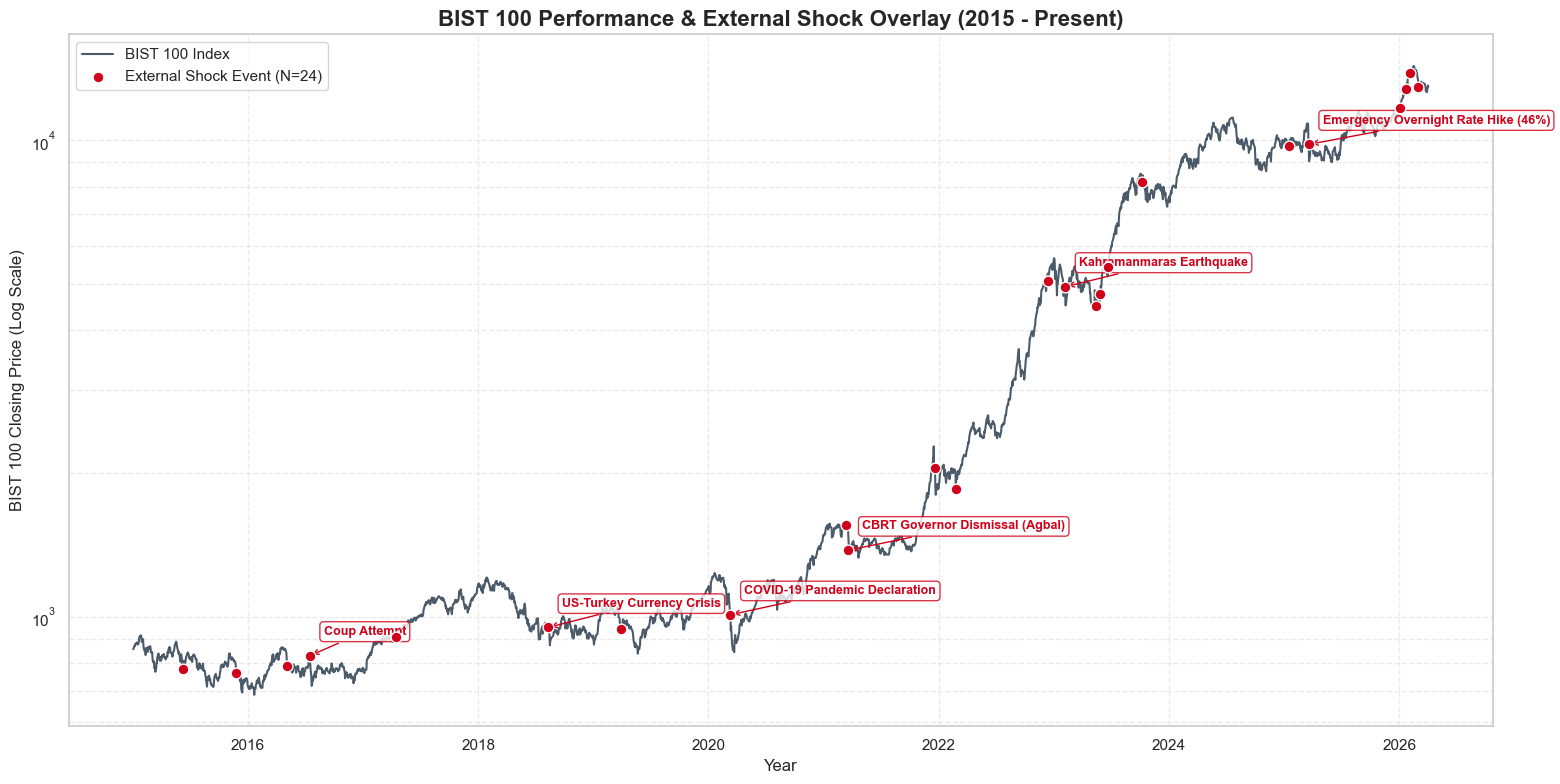

In [2]:
# 1. Plotting Setup
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# 2. Plot the main Price Line (Log Scale)
plt.plot(
    df_daily['date'], 
    df_daily['close'], 
    color='#2C3E50', 
    linewidth=1.5, 
    alpha=0.85, 
    label='BIST 100 Index'
)

# 3. Overlay ALL Shock Events
# Note: Ensure df_aligned_shocks is used here instead of the previous shocks_to_plot variable
plt.scatter(
    df_aligned_shocks['date'], 
    df_aligned_shocks['close'], 
    color='#D0021B', 
    s=60, 
    edgecolor='white', 
    linewidth=1, 
    label=f'External Shock Event (N={len(df_aligned_shocks)})',
    zorder=5
)

# 4. Add Text Annotations for 'Extreme' Severity Events
extreme_shocks = df_aligned_shocks[df_aligned_shocks['severity'] == 'Extreme']

for _, row in extreme_shocks.iterrows():
    plt.annotate(
        row['event_name'],
        xy=(row['date'], row['close']),
        xytext=(10, 15),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#D0021B',
        arrowprops=dict(arrowstyle='->', color='#D0021B', lw=1),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D0021B', alpha=0.8)
    )

# 5. Formatting
plt.title("BIST 100 Performance & External Shock Overlay (2015 - Present)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("BIST 100 Closing Price (Log Scale)", fontsize=12)
plt.yscale('log')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()

file_path = output_dir / "bist100_shock_overlay.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

## [3] Comparative Analysis: Market Volatility and Currency Correlation
This dual-plot analysis quantifies the statistical difference in BIST 100 behavior during identified crisis windows versus standard trading periods.

* **Distribution of Returns (Boxplot)**: Compares the variance in daily returns. Shock days (N=20) typically exhibit a wider spread and more extreme outliers, confirming heightened market panic.
* **Currency Interaction (Scatter Plot)**: Examines the relationship between USD/TRY movements and BIST 100 returns. This visualizes the "Currency Effect," testing if significant devaluations in the Lira correlate with immediate market sell-offs during external shocks.

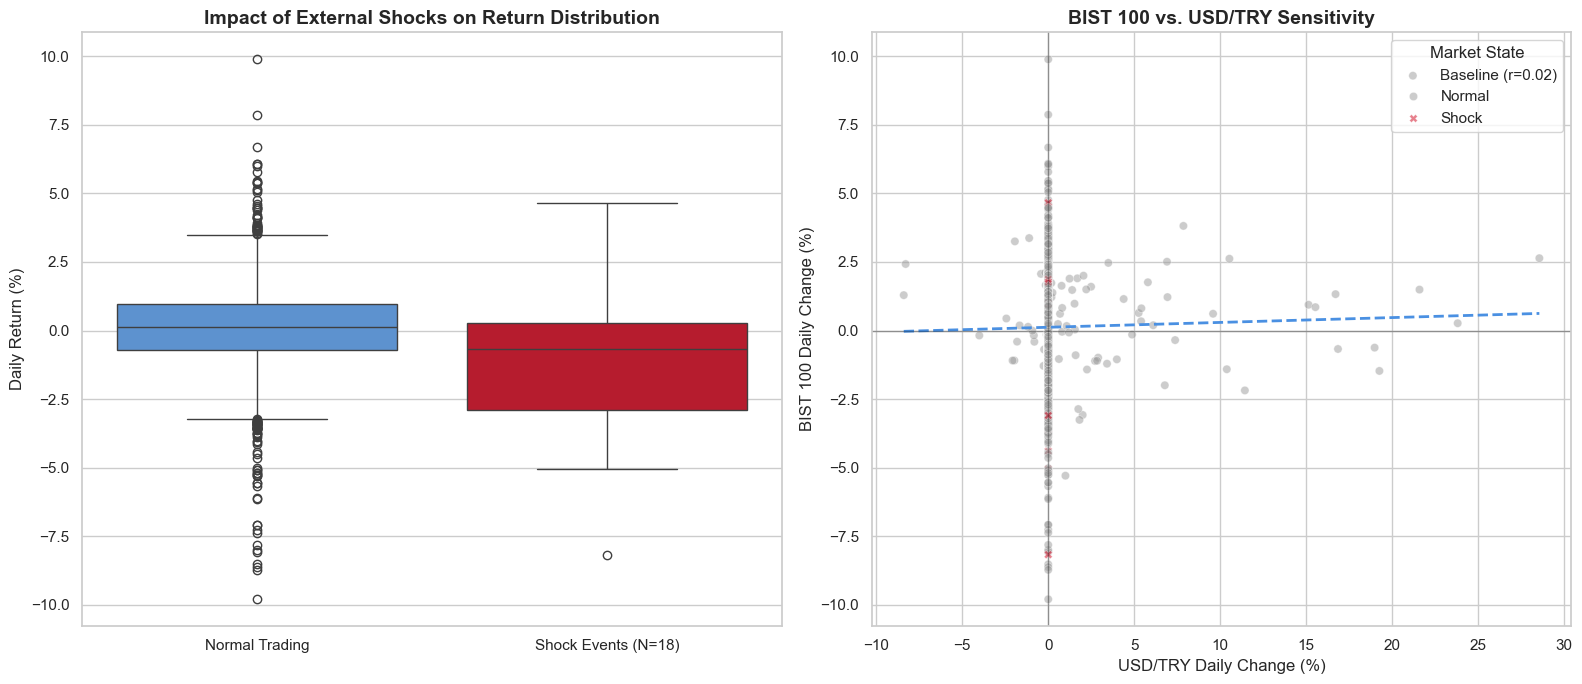

In [3]:
# Style Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

# 1. Calculation: Baseline Correlation
# Calculate daily returns for USD/TRY to compare with BIST
df_daily['usd_return_pct'] = df_daily['usd_try'].pct_change() * 100
valid_data = df_daily.dropna(subset=['usd_return_pct', 'daily_return_pct'])
correlation = valid_data['daily_return_pct'].corr(valid_data['usd_return_pct'])

# 2. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT: Return Distribution (Boxplot) ---
shock_count = df_daily[df_daily['is_shock'] == 1].shape[0]
sns.boxplot(
    x='is_shock', 
    y='daily_return_pct', 
    hue='is_shock',
    data=df_daily, 
    palette=['#4A90E2', '#D0021B'], # Professional Blue and Red
    ax=ax1,
    legend=False
)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Normal Trading', f'Shock Events (N={shock_count})'])
ax1.set_title("Impact of External Shocks on Return Distribution", fontsize=14, fontweight='bold')
ax1.set_ylabel("Daily Return (%)", fontsize=12)
ax1.set_xlabel("")

# --- RIGHT: Currency Sensitivity (Scatter Plot) ---
sns.scatterplot(
    x='usd_return_pct', 
    y='daily_return_pct', 
    hue='is_shock', 
    style='is_shock',
    palette={0: '#9B9B9B', 1: '#D0021B'}, 
    alpha=0.5,
    data=df_daily,
    ax=ax2
)

# Add Trendline for Normal Correlation
normal_days = valid_data[valid_data['is_shock'] == 0]
if not normal_days.empty:
    m, b = np.polyfit(normal_days['usd_return_pct'], normal_days['daily_return_pct'], 1)
    x_range = np.array([valid_data['usd_return_pct'].min(), valid_data['usd_return_pct'].max()])
    ax2.plot(x_range, m*x_range + b, color='#4A90E2', linestyle='--', lw=2, label=f'Baseline (r={correlation:.2f})')

# Formatting Scatter Plot
ax2.set_title("BIST 100 vs. USD/TRY Sensitivity", fontsize=14, fontweight='bold')
ax2.set_xlabel("USD/TRY Daily Change (%)", fontsize=12)
ax2.set_ylabel("BIST 100 Daily Change (%)", fontsize=12)
ax2.axhline(0, color='black', lw=1, alpha=0.3)
ax2.axvline(0, color='black', lw=1, alpha=0.3)
ax2.legend(title="Market State", labels=[f"Baseline (r={correlation:.2f})", "Normal", "Shock"])

plt.tight_layout()

file_path = output_dir / "volatility_and_currency_sensitivity.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

## [4] The Anatomy of a Shock: Event Study Visualization

This analysis focuses on the temporal impact and recovery patterns of the **BIST 100** following external shocks by centering diverse events onto a relative time scale.

* **Gray Trajectories:** Represent individual market paths for each identified shock event, normalized to 0% at $T=0$ to show the variance in reaction.
* **Bold Red Line:** Represents the average (mean) market path across all events, identifying the systemic expected behavior.
* **Shaded Area:** Represents the 95% confidence interval, illustrating the range of probable outcomes during the recovery phase.

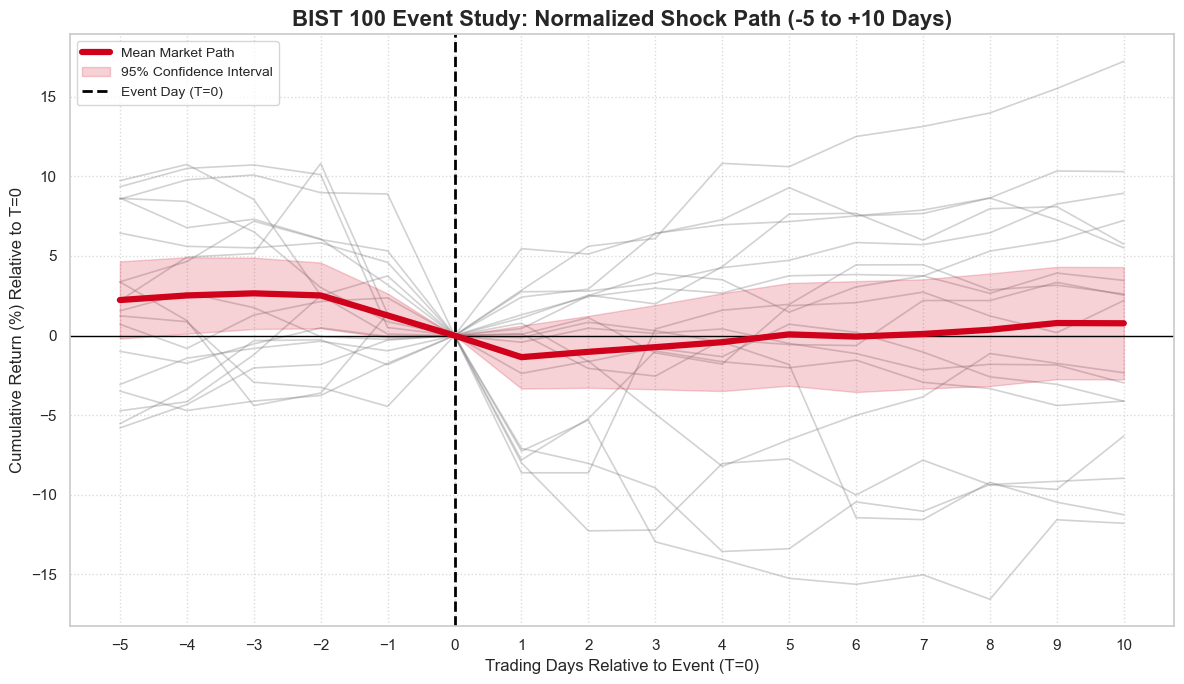

In [4]:
# 1. Preparation
df_temp = df_daily.reset_index(drop=True)
shock_indices = df_temp[df_temp['is_shock'] == 1].index

window_before, window_after = 5, 10
all_trajectories = []

# 2. Extracting Normalized Windows
for idx in shock_indices:
    if idx >= window_before and idx < (len(df_temp) - window_after):
        window_prices = df_temp.iloc[idx - window_before : idx + window_after + 1]['close']
        day_0_price = df_temp.iloc[idx]['close']
        pct_change = ((window_prices - day_0_price) / day_0_price) * 100
        all_trajectories.append(pct_change.values)

# 3. Statistical Aggregation
trajectory_matrix = np.array(all_trajectories)
mean_trajectory = trajectory_matrix.mean(axis=0)
std_err = trajectory_matrix.std(axis=0) / np.sqrt(len(all_trajectories))

# 4. Plotting
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
days = np.arange(-window_before, window_after + 1)

# Background: Individual shock paths (INCREASED VISIBILITY)
for traj in all_trajectories:
    plt.plot(days, traj, color='#7F7F7F', alpha=0.35, linewidth=1.2, zorder=1)

# Foreground: Mean path and Confidence Interval
plt.plot(days, mean_trajectory, color='#D0021B', linewidth=4.5, label='Mean Market Path', zorder=3)
plt.fill_between(days, mean_trajectory - 1.96*std_err, mean_trajectory + 1.96*std_err, 
                 color='#D0021B', alpha=0.18, label='95% Confidence Interval', zorder=2)

# Structural markers
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Event Day (T=0)')
plt.axhline(0, color='black', linestyle='-', linewidth=1)

# Formatting
plt.title("BIST 100 Event Study: Normalized Shock Path (-5 to +10 Days)", fontsize=16, fontweight='bold')
plt.xlabel("Trading Days Relative to Event (T=0)", fontsize=12)
plt.ylabel("Cumulative Return (%) Relative to T=0", fontsize=12)
plt.xticks(days)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, loc='upper left', fontsize=10)

plt.tight_layout()

file_path = output_dir / "event_study_shock_path.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()


## [5] Statistical Validation: Non-Parametric Distribution Testing

This section rigorously tests whether the market behavior during our identified shocks is fundamentally different from everyday trading noise, ensuring our visual observations carry statistical weight.

* **The Statistical Challenge:** Financial market returns naturally exhibit **"fat tails" (excess kurtosis)** and are rarely perfectly normally distributed, making standard independent T-tests unreliable.
* **The Method:** We employ the **Mann-Whitney U Test**, a robust non-parametric statistical test that evaluates whether two independent samples were drawn from populations with the same distribution.
* **The Variables:** We compare the `daily_return_pct` of everyday trading (**Normal Days**) against the specific dates flagged in our catalog (**Shock Days**).

In [5]:
# 1. Isolate the two distributions
shock_returns = df_daily[df_daily['is_shock'] == 1]['daily_return_pct'].dropna()
normal_returns = df_daily[df_daily['is_shock'] == 0]['daily_return_pct'].dropna()

# 2. Descriptive Statistics Summary
stats_summary = pd.DataFrame({
    'Metric': ['Sample Size (N)', 'Mean Return (%)', 'Volatility (Std Dev)', 'Min Return (%)', 'Max Return (%)'],
    'Normal Days': [
        len(normal_returns), 
        normal_returns.mean(), 
        normal_returns.std(), 
        normal_returns.min(), 
        normal_returns.max()
    ],
    'Shock Days': [
        len(shock_returns), 
        shock_returns.mean(), 
        shock_returns.std(), 
        shock_returns.min(), 
        shock_returns.max()
    ]
}).set_index('Metric').round(3)

print("--- 1. DESCRIPTIVE STATISTICS ---")
print(stats_summary) # <-- Replaced display() with standard print()

# 3. Mann-Whitney U Test Execution
stat, p_value = stats.mannwhitneyu(shock_returns, normal_returns, alternative='two-sided')

print("\n--- 2. HYPOTHESIS TESTING (MANN-WHITNEY U) ---")
print(f"U-Statistic: {stat}")
print(f"P-Value:     {p_value:.6e}")

# 4. Conclusion & Effect Size
if p_value < 0.05:
    volatility_ratio = shock_returns.std() / normal_returns.std()
    print("\n✅ CONCLUSION: Statistically Significant (p < 0.05)")
    print("The distribution of returns on shock days is fundamentally different from normal trading days.")
    print(f"Data Insight: Shock day volatility is {volatility_ratio:.2f}x higher than the baseline market.")
else:
    print("\n❌ CONCLUSION: Not Statistically Significant (p >= 0.05)")
    print("We cannot confidently reject the null hypothesis. The distributions are statistically similar.")

--- 1. DESCRIPTIVE STATISTICS ---
                      Normal Days  Shock Days
Metric                                       
Sample Size (N)          2798.000      18.000
Mean Return (%)             0.117      -1.162
Volatility (Std Dev)        1.552       2.961
Min Return (%)             -9.791      -8.165
Max Return (%)              9.882       4.656

--- 2. HYPOTHESIS TESTING (MANN-WHITNEY U) ---
U-Statistic: 17883.0
P-Value:     3.378634e-02

✅ CONCLUSION: Statistically Significant (p < 0.05)
The distribution of returns on shock days is fundamentally different from normal trading days.
Data Insight: Shock day volatility is 1.91x higher than the baseline market.


## [6] Market Panic Levels: Rolling Volatility Analysis

This analysis focuses on tracking structural market panic and systemic uncertainty by measuring the rolling volatility of the BIST 100 over time.

Using the daily BIST 100 returns and the identified shock catalog we:

* **calculate** a 30-day rolling standard deviation to proxy for periods of extreme market stress, and

* **overlay** the macro shocks to observe if these events precede, coincide with, or trigger major structural spikes in market volatility.

For **"Volatility,"** we utilize the 30-day rolling standard deviation of daily percentage returns.
For **"Market Panic Events,"** we highlight the specific dates of our identified external shocks directly on the volatility curve to see their immediate impact on market stability.

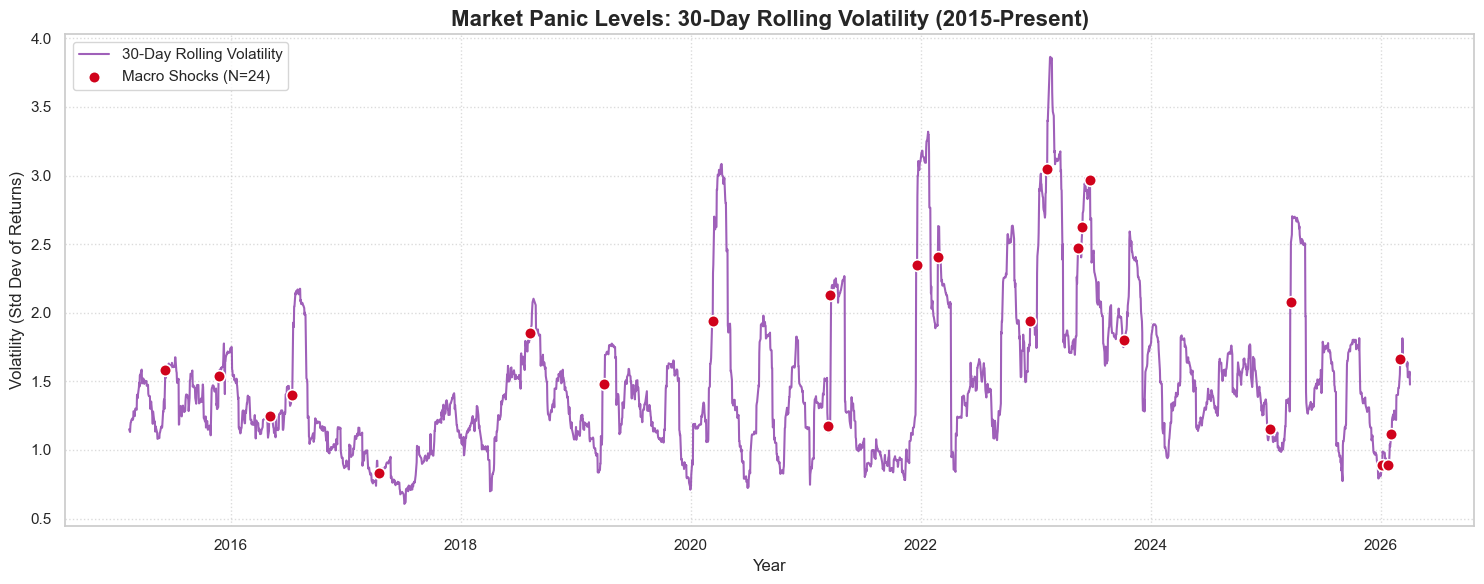

In [6]:
# 1. Calculation
# Calculate 30-day rolling standard deviation (Volatility)
df_daily['rolling_volatility_30d'] = df_daily['daily_return_pct'].rolling(window=30).std()

# Align all 24 shocks (including weekend events) to the nearest forward trading day
df_shocks_aligned_vol = pd.merge_asof(
    df_shocks.sort_values('date'), 
    df_daily[['date', 'rolling_volatility_30d']].sort_values('date'), 
    on='date', 
    direction='forward'
)

# 2. Plotting Setup
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# 3. Plot the Volatility Line
plt.plot(
    df_daily['date'], 
    df_daily['rolling_volatility_30d'], 
    color='#8E44AD', # Professional Purple 
    label='30-Day Rolling Volatility', 
    linewidth=1.5,
    alpha=0.85
)

# 4. Overlay ALL Macro Shocks
plt.scatter(
    df_shocks_aligned_vol['date'], 
    df_shocks_aligned_vol['rolling_volatility_30d'], 
    color='#D0021B', # Consistent Red from previous charts
    s=70, 
    edgecolors='white', 
    linewidth=1.2, 
    label=f'Macro Shocks (N={len(df_shocks_aligned_vol)})', 
    zorder=5
)

# 5. Formatting
plt.title("Market Panic Levels: 30-Day Rolling Volatility (2015-Present)", fontsize=16, fontweight='bold')
plt.ylabel("Volatility (Std Dev of Returns)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(frameon=True, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

file_path = output_dir / "market_panic_rolling_volatility.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

## [7] The True Market Value: BIST 100 Priced in USD

This analysis focuses on stripping away the illusion of local currency inflation to reveal the actual wealth generation or destruction in the BIST 100.

Using the daily index data and the USD/TRY exchange rate we:

* **convert** the nominal TRY closing prices into real USD terms, and

* **overlay** the macro shocks to evaluate if local market "all-time highs" are actually periods of wealth destruction for foreign or dollar-based investors.

For **"True Value,"** we divide the daily BIST 100 close by the daily USD/TRY rate.
For **"Wealth Destruction Events,"** we highlight extreme macro shocks to observe their direct impact on dollar-adjusted returns.

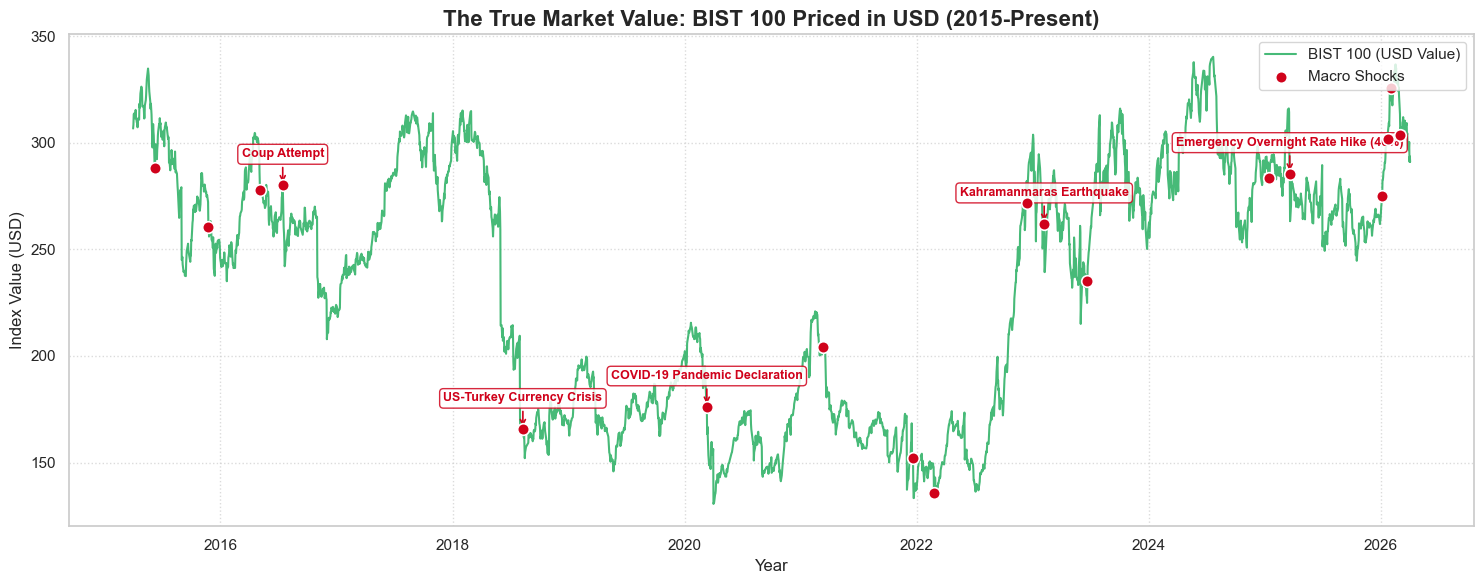

In [7]:
# 1. Calculation: Convert TRY to USD
df_daily['bist_usd'] = df_daily['close'] / df_daily['usd_try']

# 2. Alignment: Merge severity details for annotations
shocks_usd = pd.merge(
    df_daily[df_daily['is_shock'] == 1], 
    df_shocks[['date', 'event_name', 'severity']], 
    on='date', 
    how='left'
)

# 3. Plotting Setup
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot the USD Value Line
plt.plot(
    df_daily['date'], 
    df_daily['bist_usd'], 
    color='#27AE60', # Financial Green to represent USD
    label='BIST 100 (USD Value)', 
    linewidth=1.5,
    alpha=0.85
)

# Overlay Macro Shocks
plt.scatter(
    shocks_usd['date'], 
    shocks_usd['bist_usd'], 
    color='#D0021B', # Consistent Red from previous charts
    s=70, 
    edgecolors='white', 
    linewidth=1.2, 
    label='Macro Shocks', 
    zorder=5
)

# 4. Annotations for 'Extreme' Shocks
extreme_usd = shocks_usd[shocks_usd['severity'] == 'Extreme'].dropna(subset=['event_name'])
for i, row in extreme_usd.iterrows():
    plt.annotate(
        row['event_name'], 
        xy=(row['date'], row['bist_usd']), 
        xytext=(0, 20), # Offset vertically to avoid covering the line
        textcoords="offset points", 
        ha='center', 
        fontsize=9, 
        fontweight='bold', 
        color='#D0021B',
        arrowprops=dict(arrowstyle='->', color='#D0021B', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D0021B', alpha=0.85) # Professional label box
    )

# 5. Formatting
plt.title("The True Market Value: BIST 100 Priced in USD (2015-Present)", fontsize=16, fontweight='bold')
plt.ylabel("Index Value (USD)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(frameon=True, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

file_path = output_dir / "true_market_value_bist_usd.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()